🔹 What is Human-in-the-Loop (HITL) in LangGraph?

In LangGraph, Human-in-the-Loop means you pause an LLM workflow at certain nodes and wait for a human’s input, approval, or correction before continuing.

It’s implemented through the Interrupt mechanism. When a node raises an Interrupt, the graph execution pauses, and a human (or external system) provides feedback/input. Then execution resumes with the human input included in the state.

This is crucial for:

🛡️ Safety (approve before sensitive action)

✅ Validation (human checks correctness)

🎯 Customization (human adds missing context)

🔹 Analogy: Chef Cooking with an Assistant

Imagine you hire a robot chef (LLM workflow) that follows a recipe (graph).
The robot can do many steps automatically: chop, boil, fry, etc.

But for some critical steps, it pauses and asks you:

Node 1 (Prep): Robot cuts vegetables automatically.

Node 2 (Spices): Robot stops 🛑 → “Do you want mild, medium, or spicy?”

Here the human chooses (Human-in-the-Loop).

Node 3 (Cook): Robot continues cooking based on your spice level.

Node 4 (Taste Test): Robot stops again 🛑 → “Taste and confirm: Should I add more salt?”

You approve or suggest changes.

➡️ By the end, the dish is safe, tasty, and personalized because you were in the loop at key decision points.

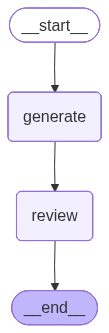

In [1]:
from langgraph.graph import StateGraph, END
from typing_extensions import TypedDict
from IPython.display import Image, display

# Define state with explicit keys
class State(TypedDict):
    query: str
    draft: str
    final: str

# Step 1: Generation node
def generate_node(state: State):
    query = state.get("query", "")  # use .get() to avoid KeyError
    draft = f"Draft answer for: {query}"
    return {"draft": draft}

# Step 2: Human review node
def human_review_node(state: State):
    print("Draft Answer:", state["draft"])
    human_input = input("Type 'approve' or enter your own edit: ")

    if human_input.lower().strip() == "approve":
        return {"final": state["draft"]}
    else:
        return {"final": human_input}  # take edited answer

# Build the graph
graph = StateGraph(State)
graph.add_node("generate", generate_node)
graph.add_node("review", human_review_node)

graph.set_entry_point("generate")
graph.add_edge("generate", "review")
graph.add_edge("review", END)

# Compile
app = graph.compile()
# View
display(Image(app.get_graph().draw_mermaid_png()))




In [2]:
# ✅ Pass query explicitly here
result = app.invoke({"query": "Explain photosynthesis in simple words"})
print("\n✅ Final Answer:", result["final"])

Draft Answer: Draft answer for: Explain photosynthesis in simple words

✅ Final Answer: Draft answer for: Explain photosynthesis in simple words


Human Feedback & Editing

🎓 Analogy

Think of this workflow as a writer–editor collaboration:

The writer (generator node) drafts.

The editor (human) can approve, rewrite, or request a revision with notes.

The draft cycles until the editor is satisfied.

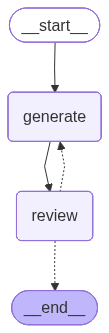

In [2]:
from langgraph.graph import StateGraph, END
from IPython.display import Image, display

# Define state
class State(dict):
    query: str
    draft: str
    final: str
    feedback: str

# Step 1: Generation node (LLM draft simulation)
def generate_node(state: State):
    query = state.get("query", "")
    feedback = state.get("feedback", "")
    if feedback:
        draft = f"Revised draft for: {query}\n(Incorporating feedback: {feedback})"
    else:
        draft = f"Draft answer to: {query}"
    return {"draft": draft, "feedback": ""}  # reset feedback after use

# Step 2: Human review node (feedback loop)
def human_review_node(state: State):
    print("\n--- Human Review Step ---")
    print("Draft Answer:", state["draft"])
    print("Options: ")
    print("  1. approve   → accept as final")
    print("  2. edit      → provide a new version")
    print("  3. revise    → send back to generation with feedback")

    choice = input("Enter choice (approve/edit/revise): ").strip().lower()

    if choice == "approve":
        return {"final": state["draft"]}
    elif choice == "edit":
        new_text = input("Enter your edited version: ")
        return {"final": new_text}
    elif choice == "revise":
        feedback = input("Enter feedback for revision: ")
        return {"feedback": feedback}
    else:
        print("Invalid choice → defaulting to draft.")
        return {"final": state["draft"]}

# Build the graph
graph = StateGraph(State)

graph.add_node("generate", generate_node)
graph.add_node("review", human_review_node)

graph.set_entry_point("generate")
graph.add_edge("generate", "review")
graph.add_conditional_edges(
    "review",
    lambda state: "generate" if "feedback" in state and state["feedback"] else END,
    {
        "generate": "generate",  # loop if feedback given
        END: END                 # exit if final approved
    }
)

# Compile
app = graph.compile()

# View
display(Image(app.get_graph().draw_mermaid_png()))

In [3]:
# Run
result = app.invoke({"query": "Explain black holes in simple terms"})
print("\n✅ Final Answer:", result["final"])


--- Human Review Step ---
Draft Answer: Draft answer to: Explain black holes in simple terms
Options: 
  1. approve   → accept as final
  2. edit      → provide a new version
  3. revise    → send back to generation with feedback
Invalid choice → defaulting to draft.

✅ Final Answer: Draft answer to: Explain black holes in simple terms


LangGraph workflow with runtime human feedback (instead of static editing). This means the system pauses at a step, asks for human input, and then continues execution with that feedback.

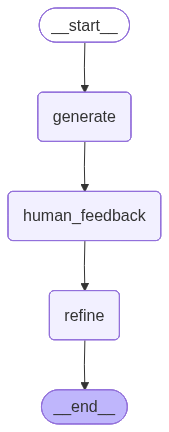

In [1]:
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from IPython.display import Image, display
from dotenv import load_dotenv
load_dotenv()

import os


os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

# 1. Define state
class State(TypedDict):
    query: str
    draft: str
    feedback: str
    final: str

# 2. LLM
from langchain_groq import ChatGroq

llm=ChatGroq(model="qwen/qwen3-32b")

# 3. Node: Generate draft answer
def generate_answer(state: State):
    response = llm.invoke(f"Answer clearly: {state['query']}")
    return {"draft": response.content}

# 4. Node: Collect human feedback (runtime)
def get_human_feedback(state: State):
    print("\n🤖 Draft Answer:", state["draft"])
    feedback = input("📝 Enter your feedback (or press Enter to accept): ")
    return {"feedback": feedback}

# 5. Node: Refine answer with feedback
def refine_answer(state: State):
    if state["feedback"].strip():
        prompt = f"Revise the answer based on this feedback: {state['feedback']}\n\nOriginal: {state['draft']}"
        response = llm.invoke(prompt)
        return {"final": response.content}
    else:
        return {"final": state["draft"]}

# 6. Graph setup
workflow = StateGraph(State)

workflow.add_node("generate", generate_answer)
workflow.add_node("human_feedback", get_human_feedback)
workflow.add_node("refine", refine_answer)

workflow.set_entry_point("generate")
workflow.add_edge("generate", "human_feedback")
workflow.add_edge("human_feedback", "refine")
workflow.add_edge("refine", END)

# 7. Compile
app = workflow.compile()

# View
display(Image(app.get_graph().draw_mermaid_png()))

In [2]:
# 8. Run
result = app.invoke({"query": "Explain quantum entanglement in simple terms"})
print("\n✅ Final Answer:", result["final"])


🤖 Draft Answer: <think>
Okay, so I need to explain quantum entanglement in simple terms. Let me start by recalling what I know. Quantum entanglement is a phenomenon where particles become linked, and the state of one instantly affects the state of the other, no matter the distance between them. But how do I simplify this without getting too technical?

First, maybe use an analogy. I remember hearing about the Einstein-Rosen-Podolsky paradox or "spooky action at a distance." Maybe I can use an analogy with coins or dice. Like if two coins are entangled, flipping one affects the other instantly. But wait, coins are classical objects, so maybe that's not the best example. Maybe use something like socks? No, socks are also classical. Maybe use something like two particles that are created together, and their properties are linked.

Wait, particles like electrons or photons. When two particles are entangled, their quantum states are connected. So if you measure one, you immediately know th